In [1]:
import gzip
import pickle
#Import HMM model
import hmmlearn.hmm as hmm # type: ignore

In [2]:
with gzip.open('dataset/train_set.pkl', 'r') as file:
    train_set = pickle.load(file)
with gzip.open('dataset/test_set.pkl', 'r') as file:
    test_set = pickle.load(file)

In [3]:
train_set = train_set.dropna()
test_set = test_set.dropna()
# Features
#features = ['avg_position','avg_position_1','avg_position_2','avg_position_3','avg_position_4']
features = ['performance_wma', 'top20_consistency', 'races_dby_consistency']
print("Features: ", features)
# Split
x_train = train_set[features]
y_train = train_set['top20']
# Test
x_test = test_set[features]
y_test = test_set['top20']

Features:  ['performance_wma', 'top20_consistency', 'races_dby_consistency']


In [4]:
hmm_model = hmm.GaussianHMM(n_components=2, covariance_type="full", n_iter=500)
hmm_model.fit(x_train)
y_pred = hmm_model.predict(x_test)

In [5]:
from sklearn.metrics import classification_report

scores = classification_report(y_test, y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.94      0.43      0.60     29391
           1       0.21      0.85      0.33      5118

    accuracy                           0.50     34509
   macro avg       0.58      0.64      0.46     34509
weighted avg       0.83      0.50      0.56     34509



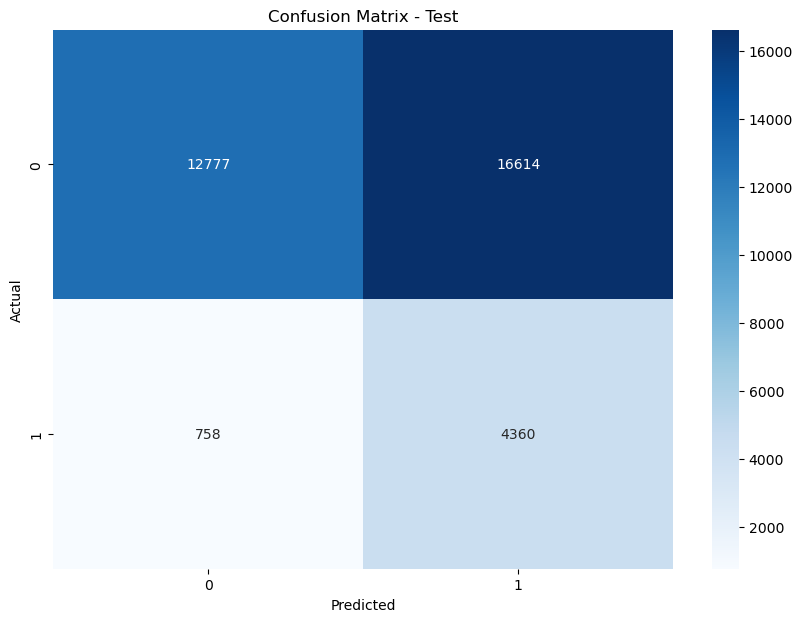

<Figure size 640x480 with 0 Axes>

In [7]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
#Plot Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.title('Confusion Matrix - Test')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
plt.clf()